In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/adult-census-income")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'adult-census-income' dataset.
Path to dataset files: /kaggle/input/adult-census-income


In [ ]:
df = pd.read_csv(path + "/adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
# data cleaning
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df.shape

(30162, 15)

In [ ]:
df1 = df.drop(['education', 'fnlwgt', 'native.country'], axis=1)
df1.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,<=50K
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,<=50K
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,<=50K
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,<=50K
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,<=50K


In [ ]:
#OHE Workclass
from sklearn.preprocessing import OneHotEncoder
ohe_work = OneHotEncoder(sparse_output = False).set_output(transform='pandas')
ohetransform_work = ohe_work.fit_transform(df[["workclass"]])
ohetransform_work.head()

,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
df1 = pd.concat([df1 , ohetransform_work] , axis = 1)
df1.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,<=50K,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,<=50K,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,<=50K,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,<=50K,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,<=50K,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
#OHE Marital Status
from sklearn.preprocessing import OneHotEncoder
ohe_mar = OneHotEncoder(sparse_output = False).set_output(transform='pandas')
ohetransform_mar = ohe_mar.fit_transform(df[["marital.status"]])
ohetransform_mar.head()

,marital.status_Divorced,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df1 = pd.concat([df1 , ohetransform_mar] , axis = 1)
df1.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,...,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital.status_Divorced,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#OHE Occupation
from sklearn.preprocessing import OneHotEncoder
ohe_occu = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')
ohetransform_occu = ohe_occu.fit_transform(df1[["occupation"]])
ohetransform_occu.head()

,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df1 = pd.concat([df1 , ohetransform_occu] , axis = 1)
df1.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,...,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#OHE Relationship
from sklearn.preprocessing import OneHotEncoder
ohe_rel = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')
ohetransform_rel = ohe_rel.fit_transform(df1[["relationship"]])
ohetransform_rel.head()

,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
1,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0
5,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df1 = pd.concat([df1 , ohetransform_rel] , axis = 1)
df1.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#OHE Race
from sklearn.preprocessing import OneHotEncoder
ohe_race = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')
ohetransform_race = ohe_race.fit_transform(df1[["race"]])
ohetransform_race.head()

,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
1,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,1.0
6,0.0,0.0,0.0,0.0,1.0


In [ ]:
df1 = pd.concat([df1 , ohetransform_race] , axis = 1)
df1.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#OHE Sex
from sklearn.preprocessing import OneHotEncoder
ohe_sex = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')
ohetransform_sex = ohe_sex.fit_transform(df1[["sex"]])
ohetransform_sex.head()

,sex_Female,sex_Male
1,1.0,0.0
3,1.0,0.0
4,1.0,0.0
5,1.0,0.0
6,0.0,1.0


In [ ]:
df1 = pd.concat([df1 , ohetransform_sex] , axis = 1)
df1.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5,34,Private,9,Divorced,Other-service,Unmarried,White,Female,0,3770,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6,38,Private,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
columns_to_drop = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex']
df1 = df1.drop(columns_to_drop, axis=1)
df1

,age,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
1,82,9,0,4356,18,<=50K,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,54,4,0,3900,40,<=50K,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,41,10,0,3900,40,<=50K,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5,34,9,0,3770,45,<=50K,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6,38,6,0,3770,40,<=50K,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,10,0,0,40,<=50K,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
32557,27,12,0,0,38,<=50K,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
32558,40,9,0,0,40,>50K,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
32559,58,9,0,0,40,<=50K,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
x = df1.drop('income', axis = 1)
y = df1['income']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape

(24129, 46)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3, metric = "manhattan")
knn.fit(x_train, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=3)

In [ ]:
y_pred = knn.predict(x_test)
y_pred

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '<=50K'],
      dtype=object)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[4085,  448],
       [ 549,  951]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.88      0.90      0.89      4533
        >50K       0.68      0.63      0.66      1500

    accuracy                           0.83      6033
   macro avg       0.78      0.77      0.77      6033
weighted avg       0.83      0.83      0.83      6033



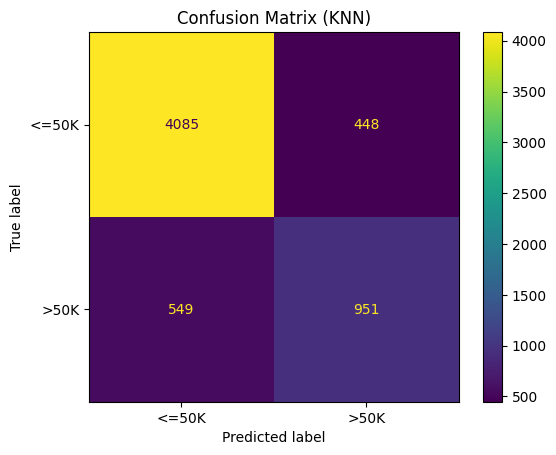

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_disp = ConfusionMatrixDisplay(cm, display_labels=["<=50K" , ">50K"])
cm_disp.plot()
plt.title("Confusion Matrix (KNN)")
plt.show()